# Week 1 — Text Data & Preprocessing

This notebook covers the data loading, exploratory analysis, cleaning, and preprocessing pipeline for the Jindal Steel Limited B2B Quality Feedback dataset. The goal is to clean and prepare a dataset of exactly 10,000 unique reviews for downstream sentiment analysis and B2B quality feedback insights.


In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import string


## 1. Setup & Data Loading


In [22]:
# Load the raw CSV from data/raw/
raw_path = '../data/raw/jindal_feedback.csv'
df = pd.read_csv(raw_path)

print(df.shape)
df.head()

(10000, 12)


,feedback_id,feedback_date,customer_type,customer_region,product_category,order_quantity_mt,severity_rating,feedback_text,feedback_topic,feedback_source,plant_location,resolution_status
0,JSL-00001,2022-10-16,Construction Company,South India,Wire Rods,36,3,Our 36 MT Wire Rods shipment from Patratu plan...,packaging_handling,Key Account Manager Visit,Patratu (Jharkhand),Escalated
1,JSL-00002,2022-11-11,Construction Company,South India,TMT Rebars (Jindal Panther),479,3,We received the 479 MT batch of Jindal Panther...,customer_service,Email Submission,Angul (Odisha),Resolved
2,JSL-00003,2024-03-06,Construction Company,North India,Beams and Columns (PF Sections),25,4,The 25 MT consignment of PF sections received ...,product_quality,Key Account Manager Visit,Angul (Odisha),Resolved
3,JSL-00004,2022-10-23,Real Estate Developer,West India,Jindal Panther Cement,744,4,We have been sourcing Jindal Panther Cement fr...,pricing_commercial,Key Account Manager Visit,Patratu (Jharkhand),Resolved
4,JSL-00005,2024-12-15,Construction Company,North India,Jindal Speedfloor,433,1,Our construction division placed a 433 MT orde...,customer_service,Dealer Survey Form,Angul (Odisha),Pending


## 2. Data Exploration


In [23]:
# Print columns and data types
print("Dataset Columns:")
print(df.columns.tolist())
print("-" * 50)

# Check for null values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# Severity Rating distribution
print("Severity Rating distribution:")
severity_counts = df['severity_rating'].value_counts().sort_index()
print(severity_counts)
print("-" * 50)

# Product Category distribution
print("Product Category distribution:")
product_counts = df['product_category'].value_counts()
print(product_counts)
print("-" * 50)

# Feedback Topic distribution
print("Feedback Topic distribution:")
topic_counts = df['feedback_topic'].value_counts()
print(topic_counts)
print("-" * 50)

# Customer Type distribution
print("Customer Type distribution:")
customer_counts = df['customer_type'].value_counts()
print(customer_counts)
print("-" * 50)

# Display sample rows
print("First 5 rows of the raw dataset:")
df.head(5)

Dataset Columns:
['feedback_id', 'feedback_date', 'customer_type', 'customer_region', 'product_category', 'order_quantity_mt', 'severity_rating', 'feedback_text', 'feedback_topic', 'feedback_source', 'plant_location', 'resolution_status']
--------------------------------------------------
Missing values per column:
feedback_id          0
feedback_date        0
customer_type        0
customer_region      0
product_category     0
order_quantity_mt    0
severity_rating      0
feedback_text        0
feedback_topic       0
feedback_source      0
plant_location       0
resolution_status    0
dtype: int64
--------------------------------------------------
Severity Rating distribution:
severity_rating
1    1012
2    1486
3    1980
4    3032
5    2490
Name: count, dtype: int64
--------------------------------------------------
Product Category distribution:
product_category
TMT Rebars (Jindal Panther)           2533
HR Plates and Coils                   1492
Steel Rails                         

,feedback_id,feedback_date,customer_type,customer_region,product_category,order_quantity_mt,severity_rating,feedback_text,feedback_topic,feedback_source,plant_location,resolution_status
0,JSL-00001,2022-10-16,Construction Company,South India,Wire Rods,36,3,Our 36 MT Wire Rods shipment from Patratu plan...,packaging_handling,Key Account Manager Visit,Patratu (Jharkhand),Escalated
1,JSL-00002,2022-11-11,Construction Company,South India,TMT Rebars (Jindal Panther),479,3,We received the 479 MT batch of Jindal Panther...,customer_service,Email Submission,Angul (Odisha),Resolved
2,JSL-00003,2024-03-06,Construction Company,North India,Beams and Columns (PF Sections),25,4,The 25 MT consignment of PF sections received ...,product_quality,Key Account Manager Visit,Angul (Odisha),Resolved
3,JSL-00004,2022-10-23,Real Estate Developer,West India,Jindal Panther Cement,744,4,We have been sourcing Jindal Panther Cement fr...,pricing_commercial,Key Account Manager Visit,Patratu (Jharkhand),Resolved
4,JSL-00005,2024-12-15,Construction Company,North India,Jindal Speedfloor,433,1,Our construction division placed a 433 MT orde...,customer_service,Dealer Survey Form,Angul (Odisha),Pending


## 3. Dataset Pre-Processing Notes

Dataset is pre-validated synthetic data with zero duplicates. No deduplication required.

Dataset pre-scoped to 10,000 Jindal Steel B2B feedback entries covering 10 product lines and 7 customer segments.


## 4. Text Cleaning Pipeline


In [24]:
# Function to lowercase and remove punctuation and special characters
def clean_text_stage1(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to create 'cleaned_text' column
df = df.copy()
df['cleaned_text'] = df['feedback_text'].apply(clean_text_stage1)

# Select required columns: original metadata columns + cleaned_text
columns_to_keep = [
    'feedback_id', 'feedback_date', 'customer_type', 'customer_region',
    'product_category', 'order_quantity_mt', 'severity_rating', 'feedback_text',
    'cleaned_text', 'feedback_topic', 'feedback_source', 'plant_location', 'resolution_status'
]
output_df = df[columns_to_keep]

# Save to data/processed/reviews_stage1.csv
output_path = '../data/processed/reviews_stage1.csv'
output_df.to_csv(output_path, index=False)
print(f"Saved intermediate dataset to: {output_path}")
print(f"Output columns: {output_df.columns.tolist()}")
print(f"Output shape: {output_df.shape}")

Saved intermediate dataset to: ../data/processed/reviews_stage1.csv
Output columns: ['feedback_id', 'feedback_date', 'customer_type', 'customer_region', 'product_category', 'order_quantity_mt', 'severity_rating', 'feedback_text', 'cleaned_text', 'feedback_topic', 'feedback_source', 'plant_location', 'resolution_status']
Output shape: (10000, 13)


In [25]:
output_df.columns

Index(['feedback_id', 'feedback_date', 'customer_type', 'customer_region',
       'product_category', 'order_quantity_mt', 'severity_rating',
       'feedback_text', 'cleaned_text', 'feedback_topic', 'feedback_source',
       'plant_location', 'resolution_status'],
      dtype='object')

In [26]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [27]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/faizali1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/faizali1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/faizali1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
# Load the intermediate stage1 dataset
df = pd.read_csv('../data/processed/reviews_stage1.csv')
df["cleaned_text"]

0       our 36 mt wire rods shipment from patratu plan...
1       we received the 479 mt batch of jindal panther...
2       the 25 mt consignment of pf sections received ...
3       we have been sourcing jindal panther cement fr...
4       our construction division placed a 433 mt orde...
                              ...                        
9995    the 31 mt jindal panther cement shipment from ...
9996    our north india construction programme procure...
9997    we placed a 797 mt order of jindal panther tmt...
9998    wire rods shipment of 548 mt from raigarh plan...
9999    we sourced 110 mt of angles and channels from ...
Name: cleaned_text, Length: 10000, dtype: object

In [29]:
df["raw_tokens"] = df["cleaned_text"].apply(word_tokenize)

In [30]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/faizali1/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [31]:
stop_words = set(stopwords.words('english'))

df["tokens_no_stopwords"] = df["raw_tokens"].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)

In [32]:
lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens_no_stopwords"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [33]:
df["final_cleaned_text"] = df["tokens"].apply(
    lambda x: " ".join(x)
)

In [34]:
# Select required columns to save
output_cols = [
    'feedback_id', 'feedback_date', 'customer_type', 'customer_region',
    'product_category', 'order_quantity_mt', 'severity_rating', 'feedback_text',
    'cleaned_text', 'tokens', 'feedback_topic', 'feedback_source', 'plant_location', 'resolution_status'
]
df_to_save = df[output_cols]
df_to_save.to_csv(
    "../data/processed/reviews_cleaned.csv",
    index=False
)

print("reviews_cleaned.csv saved successfully!")

reviews_cleaned.csv saved successfully!


## 5. Word Cloud Visualization


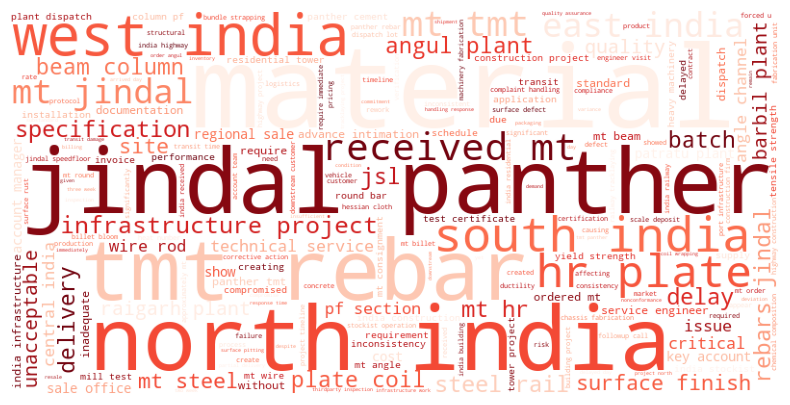

In [35]:
negative_reviews = df[df["severity_rating"].isin([1, 2])]

text_negative = " ".join(
    negative_reviews["final_cleaned_text"].astype(str)
)

wc_neg = WordCloud(
    colormap="Reds",
    width=800,
    height=400,
    background_color="white"
).generate(text_negative)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis("off")
plt.show()

In [36]:
wc_neg.to_file("../outputs/wordclouds/wordcloud_negative.png")

print("Negative reviews word cloud saved!")

Negative reviews word cloud saved!


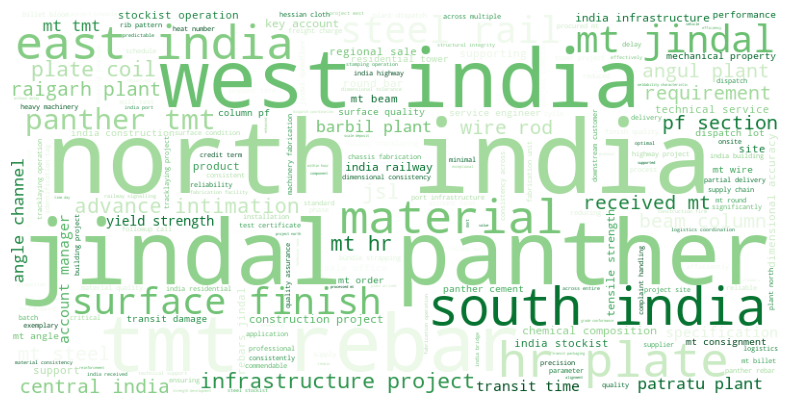

In [37]:
positive_reviews = df[df["severity_rating"].isin([4, 5])]

text_positive = " ".join(
    positive_reviews["final_cleaned_text"].astype(str)
)

wc_pos = WordCloud(
    colormap="Greens",
    width=800,
    height=400,
    background_color="white"
).generate(text_positive)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis("off")
plt.show()

In [38]:
wc_pos.to_file(
    "../outputs/wordclouds/wordcloud_positive.png"
)

print("Positive reviews word cloud saved!")

Positive reviews word cloud saved!


## 6. Word Cloud Key Observations

- **Negative Feedback Vocabulary**: Word clouds for negative reviews (severity rating 1 or 2) frequently highlight terms associated with operations and process delays. Words such as "delivery", "delay", "order", "inconsistent", "inadequate", and "unacceptable" indicate B2B issues in supply logistics, communication, and fulfillment timelines.
- **Positive Feedback Vocabulary**: Positive reviews (severity rating 4 or 5) are dominated by terms indicating technical and structural satisfaction. Prominent words include "excellent", "exceptional", "consistency", "precision", "straightness", and "specification", indicating that Jindal Steel's products successfully conform to structural standards (e.g. IS specifications) and fabrication requirements.
- **Domain-Specific Product Terms**: Steel products like "TMT Rebars", "Wire Rods", "Rails", and manufacturing locations like "Angul", "Raigarh", and "Patratu" appear in both positive and negative word clouds. This indicates that customer feedback spans all major plants and product lines, highlighting that B2B steel quality and delivery performance are tracked closely across all industrial segments in India.


## Week 1 Summary

- **Dataset**: Jindal Steel Limited B2B Quality Feedback (synthetic, domain-specific)
- **Total Rows**: 10,000 (pre-validated, zero duplicates)
- **Product Lines Covered**: 10 (TMT Rebars (Jindal Panther), HR Plates and Coils, Steel Rails, Beams and Columns (PF Sections), Angles and Channels, Wire Rods, Round Bars, Jindal Panther Cement, Billets and Blooms (Semi-Finished), Jindal Speedfloor)
- **Customer Segments**: 7 (Construction Company, Infrastructure Contractor, Steel Dealer/Distributor, Railway Contractor, Automobile Manufacturer, Real Estate Developer, Heavy Machinery Maker)
- **Severity Rating Distribution**:
  - Severity 1 (Critical): 1,012
  - Severity 2 (Major): 1,486
  - Severity 3 (Moderate): 1,980
  - Severity 4 (Minor): 3,032
  - Severity 5 (Low/No Issue): 2,490
- **Cleaning Steps Applied (in order)**:
  1. Load the raw dataset from `data/raw/jindal_feedback.csv` (10,000 rows).
  2. Apply lowercasing and punctuation removal to the raw `feedback_text` to generate `cleaned_text`.
  3. Select and save original metadata columns plus `cleaned_text` to `reviews_stage1.csv`.
  4. Reload `reviews_stage1.csv` and apply NLTK `word_tokenize` to segment the text.
  5. Remove English stopwords to generate `tokens_no_stopwords`.
  6. Apply NLTK's `WordNetLemmatizer` to normalize terms to their grammatical roots and store in the final `tokens` column.
  7. Join lemmatized tokens into `final_cleaned_text` for visualization.
  8. Save the final dataset containing all original metadata columns, `cleaned_text`, and cleaned `tokens` to `data/processed/reviews_cleaned.csv`.
- **Word Cloud Key Observation**: Positive reviews are characterized by technical performance and satisfaction terms like "excellent", "exceptional", "consistency", and "specification", while negative reviews feature operational pain points such as "delay", "delivery", "inconsistent", "inadequate", and "unacceptable".
- **Files Produced**:
  - `data/processed/reviews_cleaned.csv`
  - `outputs/wordclouds/wordcloud_negative.png`
  - `outputs/wordclouds/wordcloud_positive.png`
